In [6]:
import numpy as np
import scipy.constants as const
import matplotlib.pyplot as plt
plt.rcParams['axes.xmargin'] = 0

In [11]:
X = np.linspace(1,10,100)
order = 10 ** (np.arange(13, 20.1, 1))


ni = 1.5e10 # per cubic centimeter
T = 300 # Kelvin

In [27]:
built_in = lambda N: (const.k * T / const.e) * np.log(N/ni) * 2

In [28]:
V_bi = built_in((np.full((100,8), order).T * X).T)

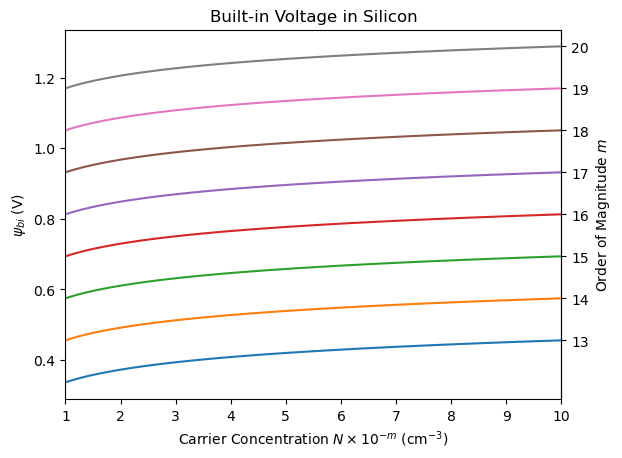

In [61]:
plt.plot(X, V_bi)
plt.xlabel(r"Carrier Concentration $N \times 10^{-m} \ (\mathrm{cm}^{-3})$")
plt.ylabel(r"$\psi_{bi} \ (\mathrm{V})$")
ax = plt.gca()
tf1 = lambda V: np.log10(ni * np.exp(V * const.e / (2 * const.k * T))) - 1
tf2 = lambda O: built_in(10 ** (O+1))
ax2 = ax.secondary_yaxis('right', (tf1, tf2))
ax2.set_ylabel(r"Order of Magnitude $m$")
ax2.set_yticks(np.arange(13, 21, dtype="float"))
plt.title("Built-in Voltage in Silicon")
plt.savefig("Problem1.png")